In [194]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import dill
import warnings
warnings.filterwarnings("ignore")

In [201]:
import json
with open("../../vtem_et_silver_city.json", "r") as file:
    vtem_et_dict = json.load(file)

In [202]:
times_orig = np.array(vtem_et_dict['times'])
currents = np.array(vtem_et_dict['currents'])
current_times = np.array(vtem_et_dict['current_times'])

In [203]:
from pathlib import Path
import pandas as pd
import glob

data_dir = Path("../../../Ruidoso_Slope/")

csv_files = sorted(data_dir.rglob("*.csv"))
csv_files_sorted = np.sort(np.array(csv_files)).tolist()
df_data = pd.concat(
    (pd.read_csv(f) for f in csv_files),
    ignore_index=True
)
df_data = df_data[~np.isnan(df_data['x'])]

In [204]:
i_start = 3
i_end = 57
data_header = np.array([f'SFz[{ii}]' for ii in range(5, 58)])[i_start:i_end]
data_header = data_header.tolist()
times = times_orig[i_start:i_end]

In [205]:
noise_level = 0.015 #0.015 pV/A/m4

In [206]:
data = df_data[data_header].values

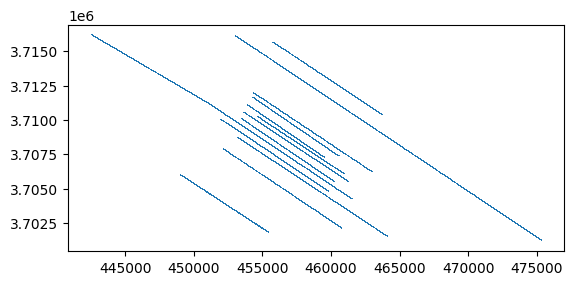

In [207]:
xy = df_data[['x', 'y']].values
plt.plot(xy[:,0], xy[:,1], ',')
plt.gca().set_aspect(1)

In [208]:
uniq_lines = np.unique(df_data['Line'].values)

In [209]:
df_data.shape[0] / 200

328.34

# Stacking raw AEM data over about 30-40 m interval (i.e. binning)

In [210]:
import pandas as pd
dx = 40.
values = []
values_std = []
for i_line, line in enumerate(uniq_lines):
    df_line = df_data[df_data['Line']==line]
    
    df_line = df_line.copy()

    xy = df_line[['x', 'y']].values
    distance = np.sqrt(((xy - xy[0,:])**2).sum(axis=1))
    n_sounding = np.round(distance.max() / dx) + 1
    bins = np.arange(n_sounding) * dx
    df_line.insert(0, 'distance', distance)
    # Bin distances
    df_line['bin'] = pd.cut(df_line['distance'], bins=bins)

    # Compute statistics per bin
    binned = (
        df_line.groupby('bin', observed=False)
               [['distance','x','y','DEM','radar','radarb','PLM'] + data_header]
               .mean()
    )
    binned.insert(0, 'line', line)
    binned_std = (
        df_line.groupby('bin', observed=False)
               [['DEM','radar','radarb'] + data_header]
               .std()
    )
    values.append(binned.values)
    values_std.append(binned_std.values)
df_data_binned = pd.DataFrame(data=np.vstack(values), columns=['Line', 'distance','x','y','DEM','radar','radarb','PLM'] + data_header)
df_data_std_binned = pd.DataFrame(data=np.vstack(values_std), columns=['DEM','radar','radarb'] + data_header)

# TODOs
- Expand the binning in a way that can handle a larger swath for the later time gates, so do it by channel [done]
- Make sure the bin interval is about 40 m while the swath could be much bigger hundres of meters 
- There are relatively large errors on early time gates due to flight height change ... how to handle?
    - problem 1: accuracy issue of the code
    - problem 2: hard to fit the data
- May be remove data greater than XX me height

In [211]:
from sklearn.preprocessing import MinMaxScaler
# Create scaler
from ipywidgets import widgets, interact

In [212]:
noise_level

0.015

In [213]:
def foo(line):
    fig, axs = plt.subplots(2,1, figsize=(20, 10))
    ax0, ax = axs

    # line = uniq_lines[i_line]
    df_data_binned_line = df_data_binned[df_data_binned['Line']==line]
    ax0.plot(df_data_binned['x'], df_data_binned['y'], '.')    
    ax0.plot(df_data_binned_line['x'], df_data_binned_line['y'], '.')
    ax0.plot(df_data_binned_line['x'].values[0], df_data_binned_line['y'].values[0], 'o')
    ax0.set_aspect(1)
    # scaler = MinMaxScaler(feature_range=(df_data_binned_line['radarb'].min(), df_data_binned_line['radarb'].max()))
    # plm_norm = scaler.fit_transform(df_data_binned_line['PLM'].values.reshape([-1,1]))

    ax_1 = ax.twinx()
    ax.semilogy(df_data_binned_line['distance'], df_data_binned_line[data_header], color='k', lw=1)
    ax.hlines(noise_level, df_data_binned_line['distance'].min(), df_data_binned_line['distance'].max(), color='r', linestyle='--')    
    ax_1.plot(df_data_binned_line['distance'], df_data_binned_line['PLM'].values, '-', color='red', label='PLM', lw=1)
    # ax_1.plot(df_data_binned_line['distance'], df_data_binned_line['radarb'], '-', label='Flight height')

    ax_1.legend()
interact(foo, line=widgets.Select(options=uniq_lines))

interactive(children=(Select(description='line', options=('T6000', 'T6010', 'T6020', 'T6030', 'T6060', 'T6070'…

<function __main__.foo(line)>

In [214]:
plm_thres = np.percentile(df_data_binned['PLM'], 75)
print (plm_thres)

0.7273412781338383


In [230]:
n_channel = len(times)
data = df_data_binned[data_header].values.astype(float)
data_rerr = (df_data_std_binned[data_header].values / abs(df_data_binned[data_header].values)).astype(float)
inds = np.logical_and(data > noise_level, data_rerr>0.15) & (np.tile(df_data_binned['PLM'].values, (n_channel, 1)).T<plm_thres)
print (f"Percentage of the total noisy data is {inds.sum() / np.prod(data.shape) * 100:.2f}%")

Percentage of the total noisy data is 0.62%


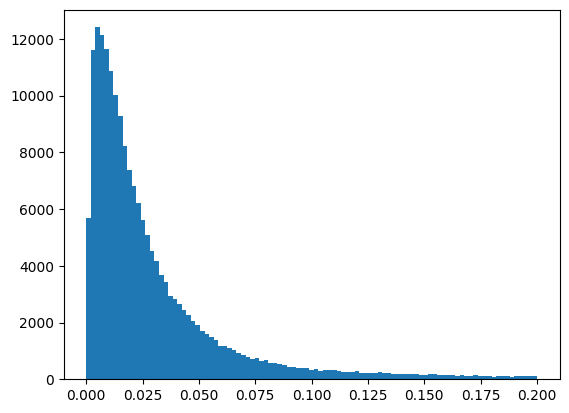

In [231]:
out = plt.hist(data_rerr.flatten(), bins=np.linspace(0, 0.2, 100))

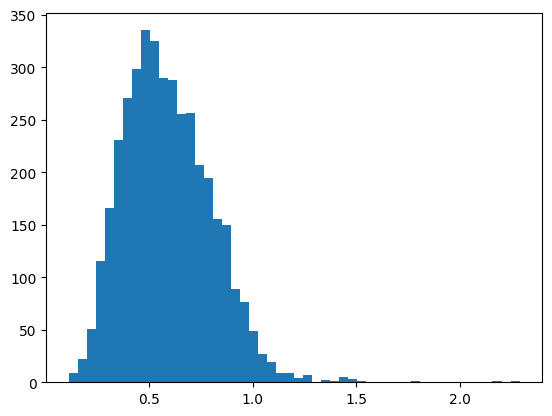

In [232]:
out = plt.hist(df_data_binned['PLM'], bins=50)

In [233]:
np.prod(data.shape)

196100

In [234]:
np.prod(inds.shape)

196100

In [235]:
noisy_counts_channels = inds.sum(axis=0)
noisy_counts_soundings = inds.sum(axis=1)

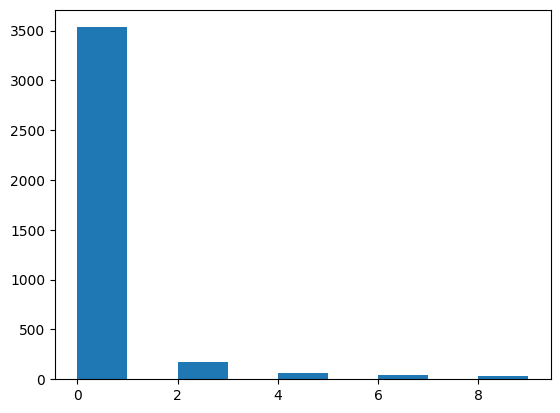

In [236]:
out = plt.hist(noisy_counts_soundings/n_channel*100, np.arange(10))


In [237]:
n_sounding = data.shape[0]
n_channel = data.shape[1]

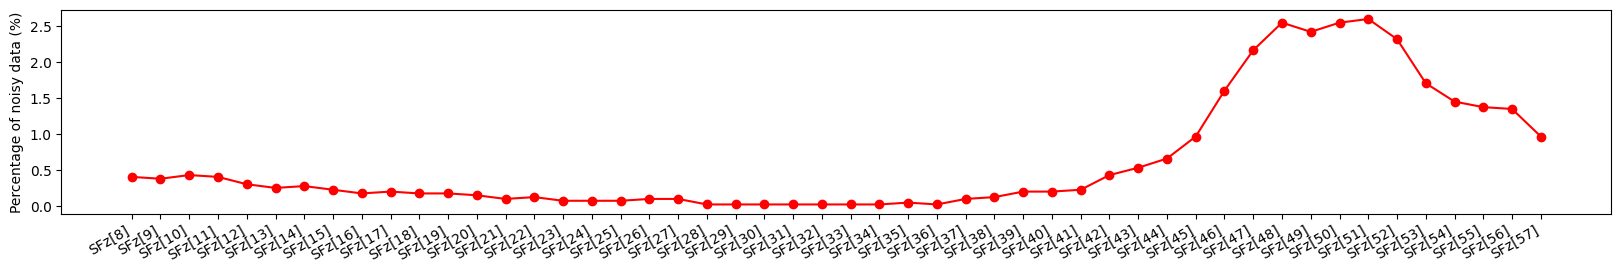

In [238]:
fig = plt.figure(figsize=(20, 3))
plt.plot(data_header, noisy_counts_channels/n_sounding * 100, 'ro-')
plt.ylabel("Percentage of noisy data (%)")
fig.autofmt_xdate()

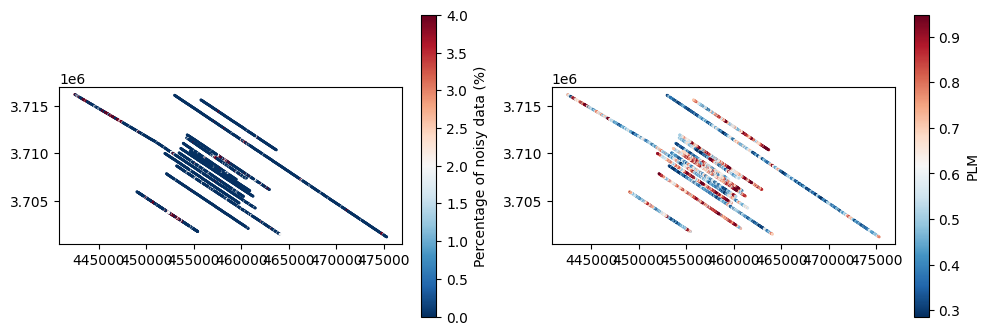

In [239]:
fig, axs = plt.subplots(1,2, figsize=(10, 8))
ax1, ax2 = axs
out = ax1.scatter(
    df_data_binned['x'], df_data_binned['y'], c=noisy_counts_soundings/n_channel*100, 
    vmin=np.percentile(noisy_counts_soundings/n_channel*100, 5), vmax=np.percentile(noisy_counts_soundings/n_channel*100, 95),
    s=1, 
    cmap='RdBu_r'
)
cb = plt.colorbar(out, fraction=0.04)
cb.set_label("Percentage of noisy data (%)")

out = ax2.scatter(
    df_data_binned['x'], df_data_binned['y'], c=df_data_binned['PLM'], s=1, 
    vmin=np.percentile(df_data_binned['PLM'], 5), vmax=np.percentile(df_data_binned['PLM'], 95),
    cmap='RdBu_r'
)
cb = plt.colorbar(out, fraction=0.04)
cb.set_label("PLM")
for ax in axs:
    ax.set_aspect(1)
plt.tight_layout()